# Read data

In [ ]:
import os
import pandas as pd

file = os.path.join("resources", "snapshot_ias_denmark_2025_25.11.1.parquet")

df = pd.read_parquet(file)

# Select images

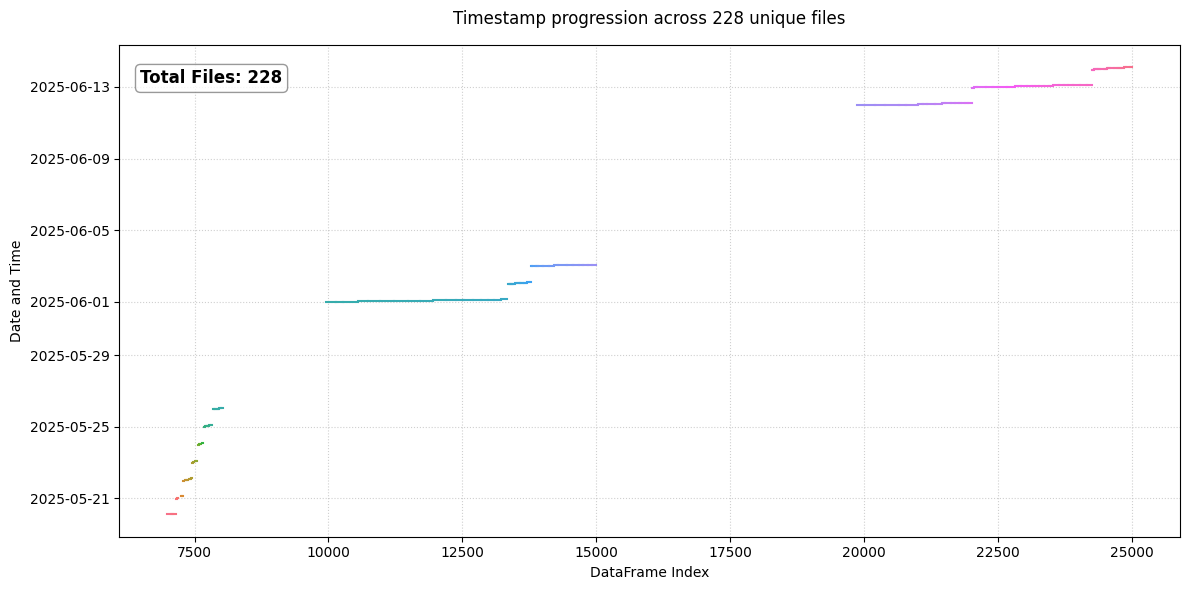

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert timestamp (Auto-detecting s vs ms)
# If the first value is very large, it's likely milliseconds
first_val = df['timestamp'].iloc[0]
ts_unit = 'ms' if first_val > 1e12 else 's'
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit=ts_unit)

# 2. Filter for the specific filenames
target_filenames = set(
    pd.concat((
        df.filename.iloc[7000:8000],
        df.filename.iloc[10000:15000], 
        df.filename.iloc[20000:25000]
        )
    )
)
filtered_df = df[df.filename.isin(target_filenames)].copy()
num_files = len(target_filenames)

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_df, 
    x=filtered_df.index, 
    y="timestamp_dt", 
    hue="filename",
    legend=False  # Removing the legend as requested
)

# 4. Adding the file count in a legible way
# We use a box with a slight background to make it pop
plt.text(
    0.02, 0.95, f"Total Files: {num_files}", 
    transform=plt.gca().transAxes, 
    fontsize=12, fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.title(f"Timestamp progression across {num_files} unique files", pad=15)
plt.ylabel("Date and Time")
plt.xlabel("DataFrame Index")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Construct example dataset

In [44]:
import os
import requests

EXAMPLE_DIR = os.path.join("..", "data")
os.makedirs(EXAMPLE_DIR, exist_ok=True)
files = dict(set([(file, url) for file, url in zip(filtered_df["filename"], filtered_df["url"])]))


for file, url in files.items():
    dst = os.path.join(EXAMPLE_DIR, file)
    if os.path.exists(dst):
        continue
    req = requests.get(url)
    with open(dst, "wb") as f:
        for chunk in req.iter_content(chunk_size=512*1024):
            if chunk:
                f.write(chunk)

final_df = filtered_df.drop("timestamp_dt", axis=1)
final_df.to_parquet(os.path.join(EXAMPLE_DIR, "metadata.parquet"))